# Computational Modeling Random Walk

## SUmmary:

WE will go over the simulation of 1D Random Walk with absorbing limits $-L, L$ Then compute the _Mean First Passage Time_ $\langle T \rangle $ and plot it as a function of $L$. WE show that the time steps needed $T$ will scale diffusivvely. By comparing the theoretical result for $L^2$ with the simulated result.

We define our step with a Bernoulli random variable $X$ with probability $p$, and we shift it by $2X - 1$ to get output of $X$ to be ${-1,1}$

In [168]:

import numpy as np
import matplotlib.pyplot as plt


def bern(p):
    return 2 * np.random.binomial(1, p) - 1

class simulate():
    def __init__(self, x_0, N, L):
        self.N = N
        self.L = L
        self.x_0 = 0

    def run_1d(self):
        path = [self.x_0]
        
        for i in range(self.N):
            x = path[i] + bern(0.5)
            if - self.L <= x <= self.L:
                path.append(x)
            else:
                break
        return path, len(path)
    
    def plot(self):
        path, T = self.run_1d()
        
        plt.plot(path)
        plt.xlabel("Time")
        plt.ylabel("Position")
        plt.title("1D Random Walk with Boundaries")
        plt.show()








Path: 
 [0, 1, 0, -1, 0, -1, -2, -3, -4, -5, -4, -5, -4, -3, -4, -3, -2, -3, -2, -1, 0, 1, 0, 1, 2, 1, 2, 3, 2, 1, 0, 1, 2, 3, 4, 5, 4, 3, 4, 3, 2, 1, 0, -1, -2, -3, -2, -3, -2, -3, -4, -5, -6, -5, -4, -3, -2, -3, -4, -3, -2, -1, 0, -1, -2, -3, -2, -3, -2, -1, -2, -3, -4, -5, -4, -5, -6, -5, -4, -5, -6, -5, -4, -5, -6, -5, -6, -7, -8, -9, -8, -9, -10, -9, -10]
Number of steps: 95


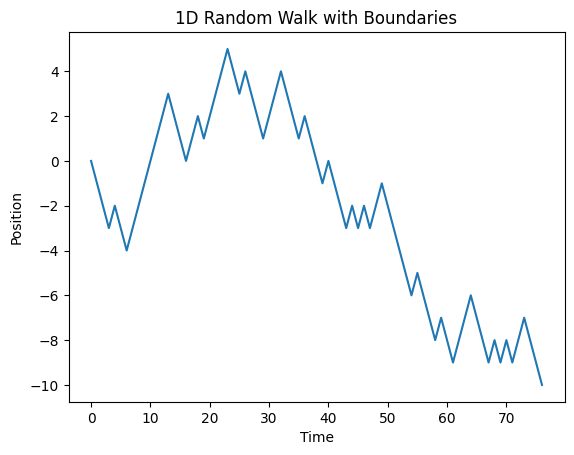

In [169]:
# Example Usage

ss1 = simulate(0, 1000, 10)

path, T = ss1.run_1d()

print(f'Path: \n {path}')
print(f'Number of steps: {T}')

ss1.plot()

# Part (b)

In [170]:
L_list = [4,8,16,32,64]
N = 5000

mean_T = []

for L in L_list:

    times = []

    for _ in range(N):

        s = simulate(0,100000,L)
        path, T = s.run_1d()
        times.append(T)

    mean_T.append(np.mean(times))

print(mean_T)

[np.float64(24.6152), np.float64(79.684), np.float64(296.468), np.float64(1080.3068), np.float64(4290.896)]


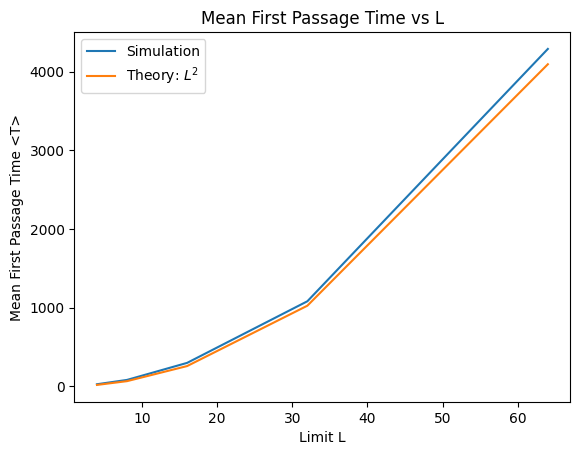

In [171]:
plt.figure()

plt.plot(L_list, mean_T, label="Simulation")

# theoretical prediction
L = np.array(L_list)
plt.plot(L, L**2, label="Theory: $L^2$")

plt.xlabel("Limit L")
plt.ylabel("Mean First Passage Time <T>")
plt.title("Mean First Passage Time vs L")
plt.legend()

plt.show()

# Self Avoiding Walk in 2D 

## Self-Avoiding Walk (SAW) in 2D

 Models a polymer chain as a random walk on a lattice with the constraint that the walker cannot visit the same lattice site twice.

We consider a square lattice where the walker starts at the origin:

$$ (x_0, y_0) = (0,0) $$

At each step the walker moves to one of the four nearest neighbors:

$$ (x,y) \rightarrow (x\pm1, y), (x, y\pm1) $$

If the walker becomes trapped, the run ends.

We generate many successful walks and compute the **mean square end-to-end distance**

$$ \langle R^2 \rangle = \langle x_N^2 + y_N^2 \rangle $$

where $(x_N,y_N)$ is the position after $N$ steps.

For polymers the scaling law is
$$ \sqrt{\langle R^2 \rangle} \propto N^\nu $$

We determine the exponent  $\nu$ using a **log-log plot**.

# Part (a)

The definition of the randomness of choice is done uniformly instead of using a bernoulli random variable. This is one of the main differences. However, given that the choice of $p$ was 0.5 for 1D walk, it is the same.

In [181]:
import numpy as np
import random


class SAW(simulate):

    def available(self, x, y, visited):
        neighbors = [
            (x+1, y),
            (x-1, y),
            (x, y+1),
            (x, y-1)
        ]

        return [n for n in neighbors if n not in visited]
        


    def run_2d(self):
        while True:
            x, y = 0, 0
            visited = {(x, y)}
            path = [(x, y)]

            for i in range(self.N):

                moves = self.available(x, y, visited)

                if len(moves) == 0:
                    break

                x, y = random.choice(moves)

                visited.add((x, y))
                path.append((x, y))

            if len(path) == self.N + 1:
                return path

    def plot(self):

        path = self.run_2d()

        x = [p[0] for p in path]
        y = [p[1] for p in path]

        plt.figure()

        plt.plot(x, y, '-o', markersize=4)
        plt.scatter(x[0], y[0], label="start")
        plt.scatter(x[-1], y[-1], label="end")

        plt.xlabel("x")
        plt.ylabel("y")
        plt.title("Self-Avoiding Walk")

        plt.axis("equal")
        plt.grid(True)
        plt.legend()

        plt.show()

[(0, 0), (-1, 0), (-1, 1), (-1, 2), (0, 2), (0, 1), (1, 1), (2, 1), (3, 1), (3, 2), (4, 2), (5, 2), (6, 2), (6, 1), (5, 1), (4, 1), (4, 0), (5, 0), (5, -1), (6, -1), (6, -2), (7, -2), (7, -1), (7, 0), (7, 1), (7, 2), (7, 3), (7, 4), (8, 4), (8, 3), (8, 2), (8, 1), (9, 1), (9, 2), (10, 2), (10, 3), (9, 3), (9, 4), (10, 4), (11, 4), (12, 4), (12, 3), (12, 2), (13, 2), (13, 1), (14, 1), (15, 1), (16, 1), (16, 2), (17, 2), (18, 2), (18, 3), (19, 3), (19, 4), (18, 4), (17, 4), (17, 3), (16, 3), (16, 4), (16, 5), (15, 5), (15, 4), (15, 3), (15, 2), (14, 2), (14, 3), (14, 4), (13, 4), (13, 5), (13, 6), (12, 6), (12, 5), (11, 5), (11, 6), (11, 7), (10, 7), (10, 8), (11, 8), (11, 9), (10, 9), (9, 9), (9, 8), (8, 8), (8, 7), (8, 6), (8, 5), (7, 5), (6, 5), (6, 4), (6, 3), (5, 3), (4, 3), (4, 4), (5, 4), (5, 5), (5, 6), (6, 6), (7, 6), (7, 7), (7, 8), (7, 9), (6, 9), (6, 10), (5, 10), (5, 11), (4, 11), (4, 10), (4, 9), (3, 9), (3, 10), (3, 11), (2, 11), (2, 10), (2, 9), (2, 8), (1, 8), (0, 8), (0

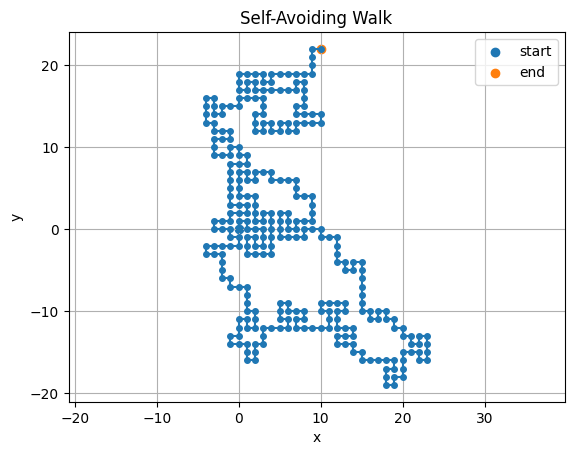

In [173]:
# Example Usage
saw = SAW(0, 300, None)

path = saw.run_2d()

print(path)

saw.plot()

# Part(b)

In [174]:
def meann(N, M=1000):

    R2 = []

    for i in range(M):

        saw = SAW(0, N, None)

        path = saw.run_2d()

        x, y = path[-1]

        R2.append(x**2 + y**2)

    return np.mean(R2)

In [175]:
N_list = [5,10,15,20,25,30]
R2_list = []

for N in N_list:
    R2_list.append(mean_R2(N))

print(R2_list)

[np.float64(8.904), np.float64(22.178), np.float64(36.608), np.float64(51.994), np.float64(70.936), np.float64(89.186)]


In [176]:
logN = np.log(N_list)
logR2 = np.log(R2_list)

slope, intercept = np.polyfit(logN, logR2, 1)

nu = slope / 2

print("nu =", nu)

nu = 0.6405045898101589


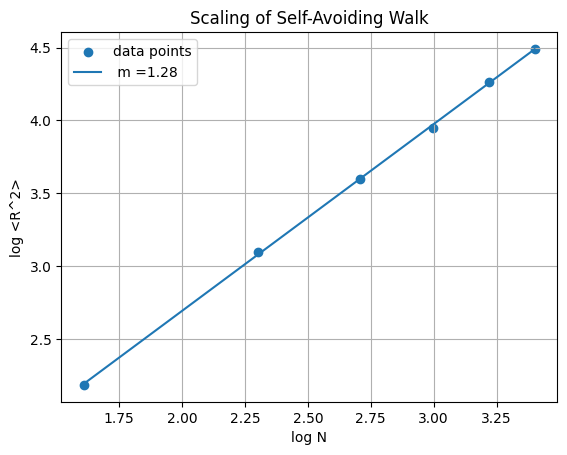

In [177]:
plt.figure()

plt.scatter(logN, logR2, label="data points")

plt.plot(logN, slope*logN + intercept,
         label=f" m ={slope:.2f}")
plt.xlabel("log N")
plt.ylabel("log <R^2>")
plt.title("Scaling of Self-Avoiding Walk")

plt.legend()
plt.grid(True)

plt.show()

In [178]:
def attrition_rate(N, attempts=2000):
    trapped = 0

    for _ in range(attempts):

        saw = SAW(0, N, None)

        x, y = 0, 0
        visited = {(x, y)}

        for step in range(N):

            moves = saw.available(x, y, visited)

            if len(moves) == 0:
                trapped += 1
                break

            x, y = random.choice(moves)
            visited.add((x, y))
    return trapped / attempts

In [179]:
N_values = np.linspace(5,1000, 40)

attrition = []

for N in N_values:
    rate = attrition_rate(int(N))
    attrition.append(rate)

print(attrition)

[0.0, 0.202, 0.4645, 0.676, 0.799, 0.877, 0.935, 0.961, 0.9735, 0.9885, 0.9945, 0.994, 0.999, 0.998, 1.0, 1.0, 0.9995, 0.9995, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


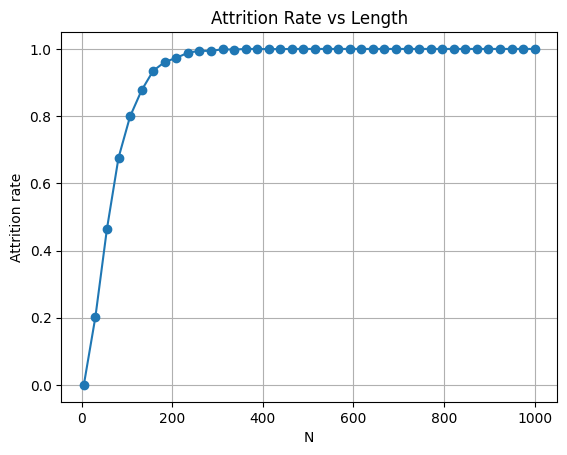

In [180]:
plt.figure()

plt.plot(N_values, attrition, 'o-')

plt.xlabel("N")
plt.ylabel("Attrition rate")

plt.title("Attrition Rate vs Length")

plt.grid(True)

plt.show()

Attrition rate stagnates given that at some point all paths will begin to get trapped. 